<a href="https://colab.research.google.com/github/Durucill/DSA210-Spring2026-Project/blob/main/ML-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

        Date  Netflix_Count  Snack_Order
0 2022-04-09              8            1
1 2022-04-14              3            1
2 2022-04-18              2            1
3 2022-04-29              1            1
4 2022-04-30              2            0
                                Date  Netflix_Count  Snack_Order
count                            402     402.000000   402.000000
mean   2024-01-10 23:42:05.373134592       3.582090     0.751244
min              2022-04-09 00:00:00       1.000000     0.000000
25%              2023-03-07 12:00:00       1.000000     1.000000
50%              2023-12-23 00:00:00       2.000000     1.000000
75%              2024-09-10 12:00:00       4.000000     1.000000
max              2026-04-09 00:00:00      27.000000     1.000000
std                              NaN       4.118504     0.432831

Missing values:
 Date             0
Netflix_Count    0
Snack_Order      0
dtype: int64


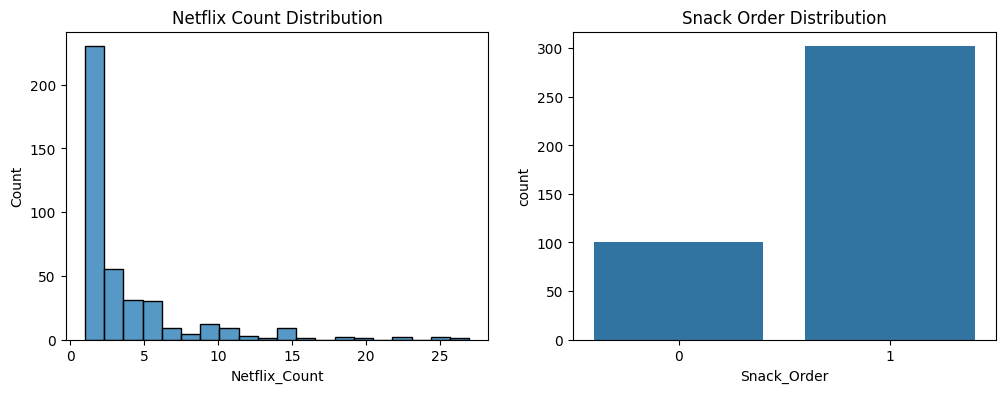

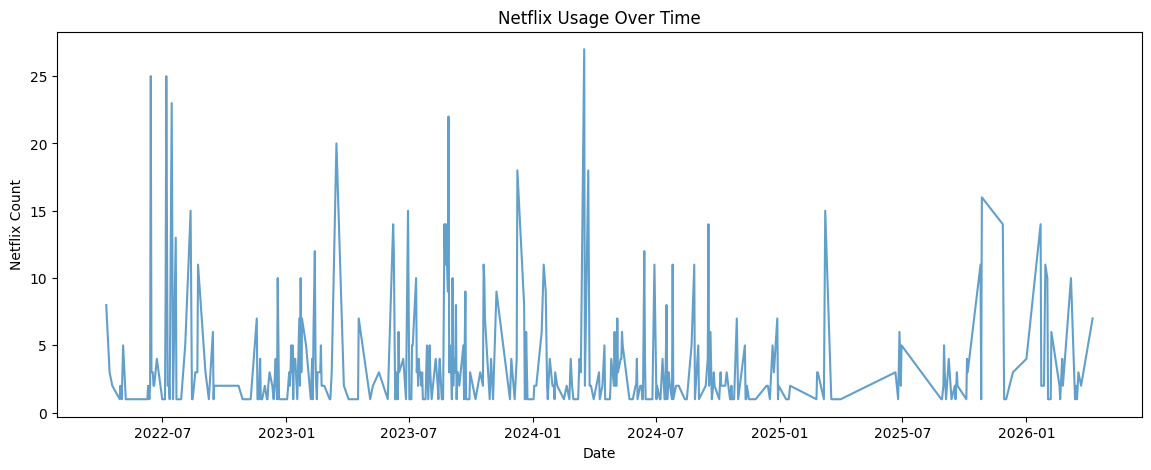

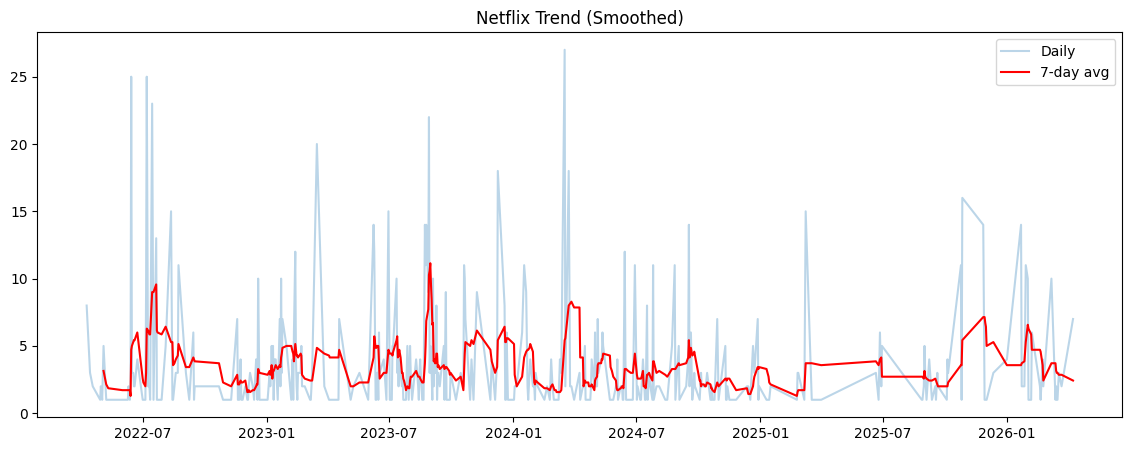

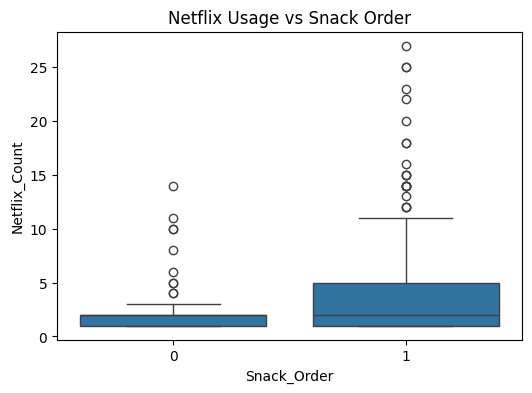

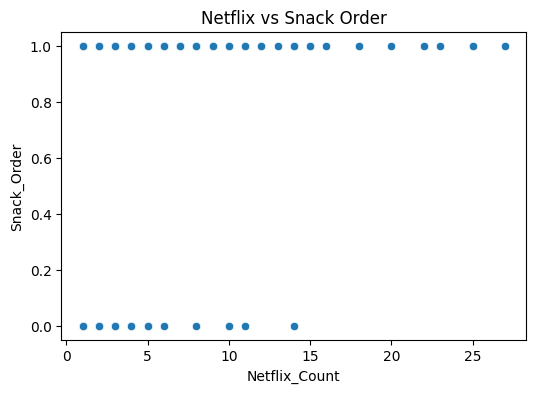

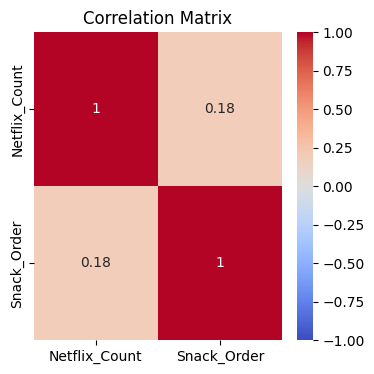


Correlation Matrix:
                Netflix_Count  Snack_Order
Netflix_Count       1.000000     0.184952
Snack_Order         0.184952     1.000000

Pearson Correlation: 0.1849518949543895
P-value: 0.00019228175895060585

Average Netflix usage:
Snack_Order
0    2.260000
1    4.019868
Name: Netflix_Count, dtype: float64

Lag correlation (Netflix → Next day snack):
                Netflix_Count  Snack_Next_Day
Netflix_Count        1.000000        0.018709
Snack_Next_Day       0.018709        1.000000


In [6]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# ----------------------
# LOAD DATA
# ----------------------
df = pd.read_excel("snack_netflix_4years.xlsx")

# ----------------------
# CLEANING
# ----------------------
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"])

df["Netflix_Count"] = pd.to_numeric(df["Netflix_Count"], errors="coerce").fillna(0)
df["Snack_Order"] = pd.to_numeric(df["Snack_Order"], errors="coerce").fillna(0)

print(df.head())
print(df.describe())

# ----------------------
# MISSING VALUES
# ----------------------
print("\nMissing values:\n", df.isnull().sum())

# ----------------------
# DISTRIBUTIONS
# ----------------------
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df["Netflix_Count"], bins=20)
plt.title("Netflix Count Distribution")

plt.subplot(1,2,2)
sns.countplot(x=df["Snack_Order"])
plt.title("Snack Order Distribution")

plt.show()

# ----------------------
# TIME SERIES
# ----------------------
df_sorted = df.sort_values("Date")

plt.figure(figsize=(14,5))
plt.plot(df_sorted["Date"], df_sorted["Netflix_Count"], alpha=0.7)
plt.title("Netflix Usage Over Time")
plt.xlabel("Date")
plt.ylabel("Netflix Count")
plt.show()

# ----------------------
# ROLLING AVERAGE
# ----------------------
df_sorted["Netflix_Rolling"] = df_sorted["Netflix_Count"].rolling(7).mean()

plt.figure(figsize=(14,5))
plt.plot(df_sorted["Date"], df_sorted["Netflix_Count"], alpha=0.3, label="Daily")
plt.plot(df_sorted["Date"], df_sorted["Netflix_Rolling"], color="red", label="7-day avg")
plt.legend()
plt.title("Netflix Trend (Smoothed)")
plt.show()

# ----------------------
# BOXPLOT (RELATIONSHIP)
# ----------------------
plt.figure(figsize=(6,4))
sns.boxplot(x="Snack_Order", y="Netflix_Count", data=df)
plt.title("Netflix Usage vs Snack Order")
plt.show()

# ----------------------
# 🔥 SCATTER PLOT (NEW)
# ----------------------
plt.figure(figsize=(6,4))
sns.scatterplot(x="Netflix_Count", y="Snack_Order", data=df)
plt.title("Netflix vs Snack Order")
plt.show()

# ----------------------
# CORRELATION HEATMAP
# ----------------------
corr_matrix = df[["Netflix_Count", "Snack_Order"]].corr()

plt.figure(figsize=(4,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

print("\nCorrelation Matrix:\n", corr_matrix)

# ----------------------
# 🔥 PEARSON + P-VALUE (NEW)
# ----------------------
corr, p = pearsonr(df["Netflix_Count"], df["Snack_Order"])

print("\nPearson Correlation:", corr)
print("P-value:", p)

# ----------------------
# GROUP ANALYSIS
# ----------------------
group_means = df.groupby("Snack_Order")["Netflix_Count"].mean()

print("\nAverage Netflix usage:")
print(group_means)

# ----------------------
# LAG ANALYSIS
# ----------------------
df_sorted["Snack_Next_Day"] = df_sorted["Snack_Order"].shift(-1)

lag_corr = df_sorted[["Netflix_Count", "Snack_Next_Day"]].corr()

print("\nLag correlation (Netflix → Next day snack):")
print(lag_corr)

In [7]:
# -----------------------------
# MACHINE LEARNING (STEP 1)
# -----------------------------

X = df[["Netflix_Count"]]
y = df["Snack_Order"]

print(X.head())
print(y.head())

   Netflix_Count
0              8
1              3
2              2
3              1
4              2
0    1
1    1
2    1
3    1
4    0
Name: Snack_Order, dtype: int64


In [8]:
# -----------------------------
# MACHINE LEARNING (STEP 2)
# -----------------------------

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 321
Test size: 81


In [10]:
# -----------------------------
# MACHINE LEARNING (STEP 3)
# -----------------------------

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [11]:
# -----------------------------
# MACHINE LEARNING (STEP 4)
# -----------------------------

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7160493827160493

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        23
           1       0.72      1.00      0.83        58

    accuracy                           0.72        81
   macro avg       0.36      0.50      0.42        81
weighted avg       0.51      0.72      0.60        81


Confusion Matrix:

[[ 0 23]
 [ 0 58]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
